# Trajectory path-error metrics: MULTI (Comment 26)

Figs. 9, 10 currently report only qualitative circle plots and mean +/- std
angular values; quantified here as RMS radial/height deviation from the
re-fit reference circle, across closed/open-loop, model-based/data-driven,
and with/without the 50 g disturbance. See `path_error_metrics.py`.

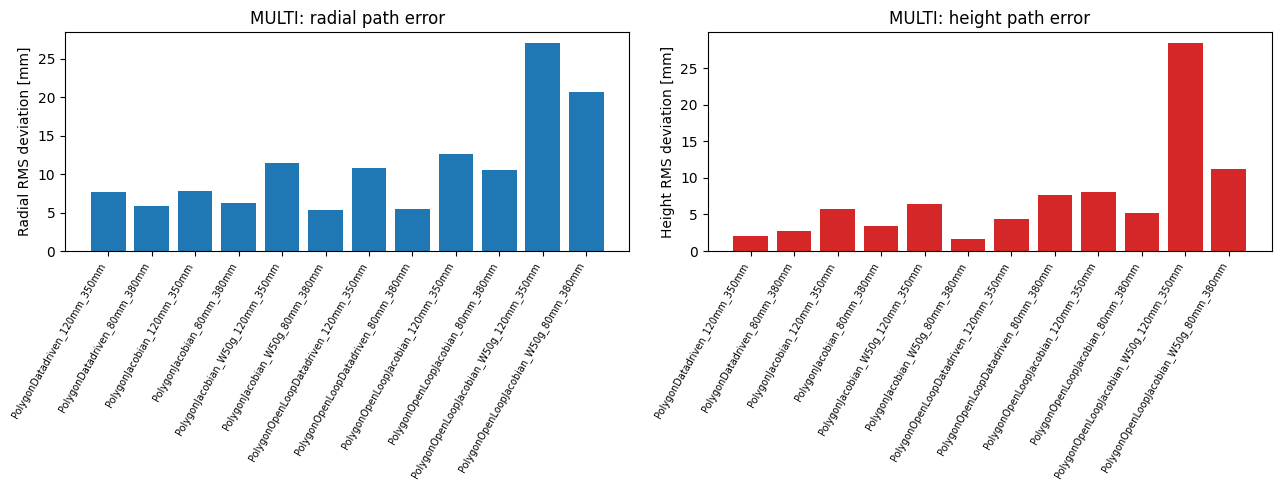

In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt

with open("results/PathErrorMetrics.json") as f:
    multi = json.load(f)

def short_name_multi(k):
    return k.split("/")[-1].replace(".npz", "").replace("30sides_", "")

labels_m = [short_name_multi(k) for k in multi]
radial_m = [v["radial_rms"] for v in multi.values()]
height_m = [v["height_rms"] for v in multi.values()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(labels_m))
axes[0].bar(x, radial_m, color="#1f77b4")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_m, rotation=60, ha="right", fontsize=7)
axes[0].set_ylabel("Radial RMS deviation [mm]"); axes[0].set_title("MULTI: radial path error")

axes[1].bar(x, height_m, color="#d62728")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels_m, rotation=60, ha="right", fontsize=7)
axes[1].set_ylabel("Height RMS deviation [mm]"); axes[1].set_title("MULTI: height path error")
plt.tight_layout()
plt.savefig("results/multi_path_error.pdf")
plt.show()


**Reading**: closed-loop consistently beats open-loop on radial deviation for
SINGLE; the clearest effect is the W50g-disturbance open-loop Jacobian runs
for MULTI, where radial/height RMS roughly double or more relative to the
undisturbed case -- a quantitative backing for the qualitative "closed-loop
recovers, open-loop fails to maintain the path" claim already in Section
4.2.6.